In [1]:
# Wspólne definicje (jak w 20260716a/b.ipynb - kopiowane, nie importowane,
# żeby ten notebook był samodzielny do uruchomienia bez zależności od
# kolejności odpalania innych notebooków).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

USGS_PATH = "../data/usgs_data/usgs_m4_2005_2025.csv"

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()

def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


def full_d_scan(cr, eq, t0, P_days, m, dt_days, d_range):
    return {d: cosmoseismic_stat(cr, eq, t0, P_days, d, m, dt_days)["PCDF"] for d in d_range}


def circular_shift_eq(eq, rng):
    start, end = eq.index.min(), eq.index.max()
    span = end - start
    shift = pd.Timedelta(seconds=int(rng.uniform(0, span.total_seconds())))
    new_idx = (start + ((eq.index - start + shift) % span)).astype(eq.index.dtype)
    return pd.Series(eq.values, index=new_idx).sort_index()


eq = load_earthquakes(min_mag=4.0)
t0 = pd.Timestamp("2013-11-14 07:00:00")  # ten sam t0 co dla Moskwy/Oulu (20260716a/b)
print(f"EQ (M>=4.0): {len(eq)} zdarzeń, {eq.index.min()} .. {eq.index.max()}")

EQ (M>=4.0): 290945 zdarzeń, 2005-01-01 00:47:34.620000 .. 2025-01-31 23:57:39.481000


In [2]:
# Loader dla Oulu (jak w 20260716b.ipynb). UWAGA: oulu_5min_data.csv ma jeden
# uszkodzony wiersz (linia 839815) - pojedyncze pole ~491k znaków "\x00\x00..."
# zamiast "datetime,value", w miejscu ~15-dniowej luki w danych z 1978 r.
# Pomijamy go przy wczytaniu (errors="coerce" + dropna), zamiast czyścić
# plik źródłowy - decyzja z 20260716b.ipynb.
#
# Ten notebook bada wpływ rozdzielczości czasowej binowania CR (5 min
# surowe -> różne resamplingi) na wynik testu kosmo-sejsmicznego, więc
# potrzebujemy danych Oulu w oryginalnej (najdrobniejszej) rozdzielczości -
# Moskwa ma dane tylko co 6h u źródła, nie da się jej dodatkowo "pocienić".
OULU_PATH = "../data/oulu_5min_data.csv"

def load_oulu():
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    n_bad = df["datetime"].isna().sum()
    if n_bad:
        print(f"load_oulu: pominięto {n_bad} niesparsowalnych wierszy (uszkodzone dane)")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"]

cr_oulu_5min = load_oulu()
print(f"CR Oulu (5 min, surowe): {len(cr_oulu_5min)} pomiarów, "
      f"{cr_oulu_5min.index.min()} .. {cr_oulu_5min.index.max()}")

load_oulu: pominięto 1 niesparsowalnych wierszy (uszkodzone dane)
CR Oulu (5 min, surowe): 5720382 pomiarów, 1970-01-01 00:00:00 .. 2025-12-31 23:50:00


In [3]:
# Konfiguracja skanu rozdzielczości.
#
# Kompromis liczba-wierszy-vs-liczba-symulacji: koszt jednej symulacji
# (full_d_scan, 30x cosmoseismic_stat) skaluje się z liczbą wierszy cr, ale
# NIE liniowo w prosty sposób (Oulu 5min: 5.7M wierszy -> 559 ms/sym; Oulu
# 6h: 82k wierszy -> 54 ms/sym - to ~10x, nie ~70x jak sugerowałby stosunek
# liczby wierszy). Dlatego zamiast zakładać skalowanie, dla KAŻDEJ
# rozdzielczości mierzymy realny czas symulacji (szybka kalibracja,
# n_calib=20) i dopiero na tej podstawie liczymy n_sims tak, żeby cały
# przebieg (kalibracja + pełne MC) zmieścił się w stałym budżecie czasu.
# Dzięki temu każda rozdzielczość kosztuje mniej więcej tyle samo czasu,
# niezależnie od tego, ile wierszy ma dany resampling.
BUDGET_SECONDS = 600  # 10 minut / rozdzielczość -> ~80 min na 8 rozdzielczości
RESOLUTIONS = ["5min", "15min", "30min", "1h", "3h", "6h", "12h", "24h"]
N_SIMS_MIN, N_SIMS_MAX = 500, 200_000  # widełki: nie za mało trafień, nie absurdalnie długo
RESULTS_CSV = "../results/resolution_scan_results.csv"

BIN_MINUTES = {"5min": 5, "15min": 15, "30min": 30, "1h": 60,
               "3h": 180, "6h": 360, "12h": 720, "24h": 1440}


def append_result_row(row, path=RESULTS_CSV):
    import os
    df_row = pd.DataFrame([row])
    header = not os.path.exists(path)
    df_row.to_csv(path, mode="a", header=header, index=False)

In [4]:
# Główna pętla: dla każdej rozdzielczości - resample, kalibracja czasu,
# n_sims z budżetu, pełne MC, zapis wyniku (.npy) + wiersz podsumowania
# (CSV, dopisywany NA BIEŻĄCO po każdej rozdzielczości - jeśli coś przerwie
# obliczenia w połowie, wcześniejsze rozdzielczości nie przepadają).
#
# Całość to ~8 x 10 min = ~80 minut. Można to uruchomić raz na całość, albo
# (jeśli wygodniej) tę komórkę powtarzać z RESOLUTIONS ograniczonym do
# pojedynczej wartości na raz - append_result_row i tak dopisuje do tego
# samego CSV.
import sys, time
sys.path.insert(0, "..")
from mc_parallel import run_mc_parallel

for res in RESOLUTIONS:
    print(f"\n=== rozdzielczość {res} ===")
    cr_res = cr_oulu_5min if res == "5min" else cr_oulu_5min.resample(res).mean()
    n_rows = len(cr_res)
    print(f"n_rows={n_rows}")

    # 1) realny best_pcdf na prawdziwych (nieprzesuniętych) danych, skan d=1..30
    sim = full_d_scan(cr_res, eq, t0, 1675, 4.0, 15, range(1, 31))
    best_d = min(sim, key=sim.get)
    best_pcdf = sim[best_d]
    print(f"best_pcdf={best_pcdf:.3e} przy d={best_d}")

    # 2) szybka kalibracja czasu (n_calib=20)
    n_calib = 20
    t_calib = time.time()
    _ = run_mc_parallel(cr_res, eq, t0, 1675, 4.0, 15, n_calib,
                         full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
                         base_seed=1)
    per_sim_time = (time.time() - t_calib) / n_calib
    print(f"per_sim_time={per_sim_time * 1000:.1f} ms")

    # 3) n_sims z budżetu czasu, przycięte do [N_SIMS_MIN, N_SIMS_MAX]
    n_sims = int(np.clip(BUDGET_SECONDS / per_sim_time, N_SIMS_MIN, N_SIMS_MAX))
    print(f"n_sims={n_sims} (budżet {BUDGET_SECONDS}s)")

    # 4) pełne MC, zapis surowego wyniku do .npy
    save_path = f"../results/mc_minima_res_{res}.npy"
    t_full = time.time()
    mc_minima = run_mc_parallel(cr_res, eq, t0, 1675, 4.0, 15, n_sims,
                                 full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
                                 base_seed=42, save_path=save_path)
    elapsed_full = time.time() - t_full

    p_global = (mc_minima <= best_pcdf).mean()
    p_global_floor = max(p_global, 1 / n_sims)
    sigma = norm.isf(p_global_floor)
    is_floor = bool(p_global == 0)

    row = dict(
        resolution=res, bin_minutes=BIN_MINUTES[res], n_rows=n_rows,
        best_d=best_d, best_pcdf=best_pcdf,
        per_sim_time_ms=per_sim_time * 1000, n_sims=n_sims,
        elapsed_full_s=elapsed_full, p_global=p_global,
        p_global_floor=p_global_floor, sigma=sigma, is_floor=is_floor,
        save_path=save_path,
    )
    append_result_row(row)
    print(f"n_sims={n_sims} w {elapsed_full:.1f}s -> p_global={p_global:.4f}, sigma={sigma:.2f}"
          f"{' (floor, 0 trafień)' if is_floor else ''}")


=== rozdzielczość 5min ===
n_rows=5720382
best_pcdf=1.042e-05 przy d=3
per_sim_time=612.3 ms
n_sims=979 (budżet 600s)
n_sims=979 w 592.6s -> p_global=0.0020, sigma=2.87

=== rozdzielczość 15min ===
n_rows=1963584
best_pcdf=1.042e-05 przy d=3
per_sim_time=209.9 ms
n_sims=2858 (budżet 600s)
n_sims=2858 w 586.7s -> p_global=0.0035, sigma=2.70

=== rozdzielczość 30min ===
n_rows=981792
best_pcdf=1.042e-05 przy d=3
per_sim_time=123.5 ms
n_sims=4858 (budżet 600s)
n_sims=4858 w 571.8s -> p_global=0.0029, sigma=2.76

=== rozdzielczość 1h ===
n_rows=490896
best_pcdf=1.042e-05 przy d=3
per_sim_time=80.8 ms
n_sims=7422 (budżet 600s)
n_sims=7422 w 551.1s -> p_global=0.0032, sigma=2.72

=== rozdzielczość 3h ===
n_rows=163632
best_pcdf=1.042e-05 przy d=3
per_sim_time=59.3 ms
n_sims=10123 (budżet 600s)
n_sims=10123 w 561.5s -> p_global=0.0035, sigma=2.70

=== rozdzielczość 6h ===
n_rows=81816
best_pcdf=4.546e-05 przy d=3
per_sim_time=55.3 ms
n_sims=10852 (budżet 600s)
n_sims=10852 w 570.5s -> p_glob

In [5]:
# Wczytanie podsumowania (działa niezależnie od tego, czy pętla wyżej
# dokończyła wszystkie rozdzielczości, czy została przerwana w połowie -
# CSV ma tyle wierszy, ile rozdzielczości zdążyło się policzyć).
results = pd.read_csv(RESULTS_CSV).sort_values("bin_minutes")
results

,resolution,bin_minutes,n_rows,best_d,best_pcdf,per_sim_time_ms,n_sims,elapsed_full_s,p_global,p_global_floor,sigma,is_floor,save_path
0,5min,5,5720382,3,0.000010,612.312186,979,592.560135,0.002043,0.002043,2.871460,False,mc_minima_res_5min.npy
1,15min,15,1963584,3,0.000010,209.931791,2858,586.695320,0.003499,0.003499,2.696944,False,mc_minima_res_15min.npy
2,30min,30,981792,3,0.000010,123.482823,4858,571.782395,0.002882,0.002882,2.760931,False,mc_minima_res_30min.npy
3,1h,60,490896,3,0.000010,80.835438,7422,551.074339,0.003234,0.003234,2.723099,False,mc_minima_res_1h.npy
4,3h,180,163632,3,0.000010,59.265625,10123,561.457477,0.003457,0.003457,2.700913,False,mc_minima_res_3h.npy
5,6h,360,81816,3,0.000045,55.288494,10852,570.510018,0.011334,0.011334,2.278974,False,mc_minima_res_6h.npy
6,12h,720,40908,3,0.000045,55.073142,10894,556.288941,0.011291,0.011291,2.280446,False,mc_minima_res_12h.npy
7,24h,1440,20454,5,0.000180,53.416455,11232,573.233675,0.019854,0.019854,2.056774,False,mc_minima_res_24h.npy


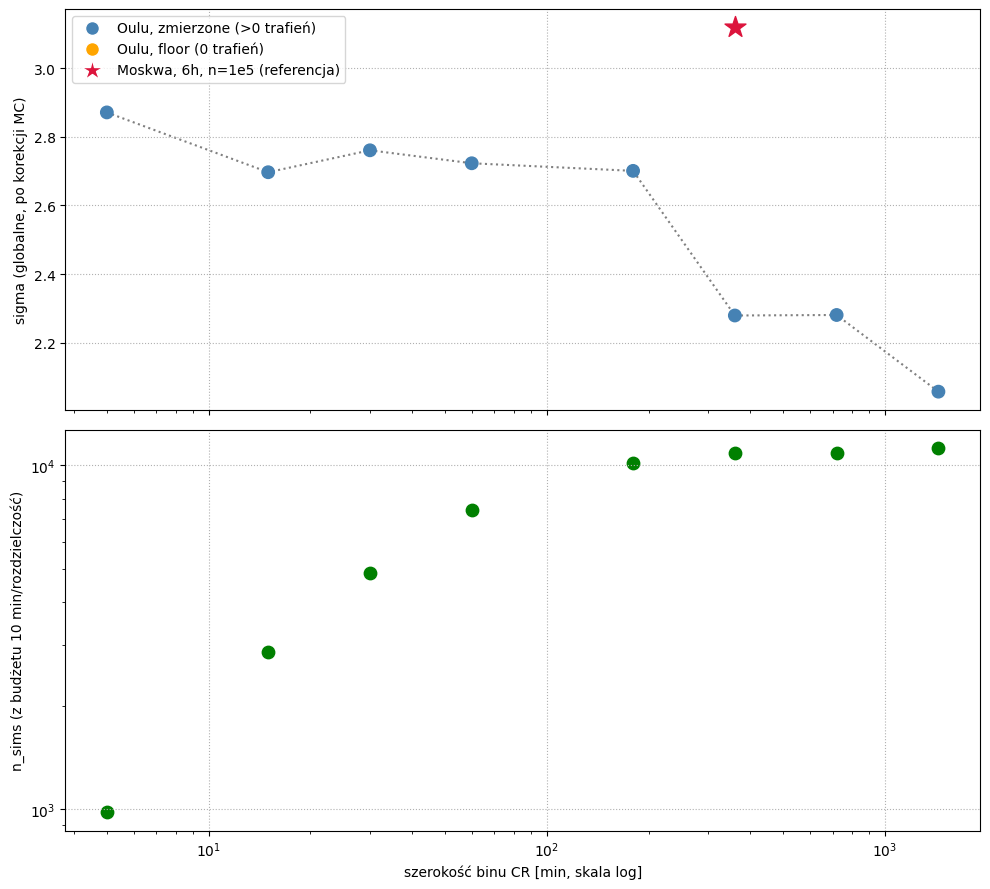

In [6]:
# Wykres: sigma (istotność globalna, po korekcji MC) w funkcji szerokości
# binu CR [min, skala log]. Punkty "floor" (0 trafień w n_sims symulacji)
# oznaczone osobnym kolorem - to dolne ograniczenie sigma, nie precyzyjny
# pomiar (patrz 20260716.txt - to samo rozróżnienie co dla Moskwy n=1000
# vs n=1e5).
#
# Linia odniesienia: Moskwa (6h, jedyna dostępna rozdzielczość u źródła),
# n_sims=1e5, sigma=3.12 (20260716a.ipynb) - dla porównania, czy Oulu przy
# tej samej szerokości binu (360 min) daje podobny wynik.
from matplotlib.lines import Line2D

MOSCOW_BIN_MINUTES = 360
MOSCOW_SIGMA = 3.12

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

colors = np.where(results["is_floor"], "orange", "steelblue")
axes[0].plot(results["bin_minutes"], results["sigma"], color="gray", ls=":", zorder=1)
axes[0].scatter(results["bin_minutes"], results["sigma"], c=colors, s=80, zorder=3)
axes[0].scatter([MOSCOW_BIN_MINUTES], [MOSCOW_SIGMA], marker="*", s=250,
                 color="crimson", zorder=4)
axes[0].set_xscale("log")
axes[0].set_ylabel("sigma (globalne, po korekcji MC)")
axes[0].grid(ls=":")
axes[0].legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=10,
           label="Oulu, zmierzone (>0 trafień)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="orange", markersize=10,
           label="Oulu, floor (0 trafień)"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="crimson", markersize=16,
           label="Moskwa, 6h, n=1e5 (referencja)"),
])

axes[1].scatter(results["bin_minutes"], results["n_sims"], color="green", s=80)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("szerokość binu CR [min, skala log]")
axes[1].set_ylabel("n_sims (z budżetu 10 min/rozdzielczość)")
axes[1].grid(ls=":")

plt.tight_layout()
plt.show()